In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from gnlse import plot_intensity

In [33]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [44]:
total_data = np.load('./total_fields_3.npy')
print(total_data.shape)
print(total_data.dtype)

(16, 21, 64, 64, 2048)
complex64


In [5]:
core_radius = 16.0e-6 / 2
Lx, Ly = 4 * core_radius, 4 * core_radius
Nx, Ny = 64, 64
extent = [-Lx/2, Lx/2, -Ly/2, Ly/2]

In [75]:
test_fields_input = total_data[-1][0]
test_fields_output = total_data[-1][-1]

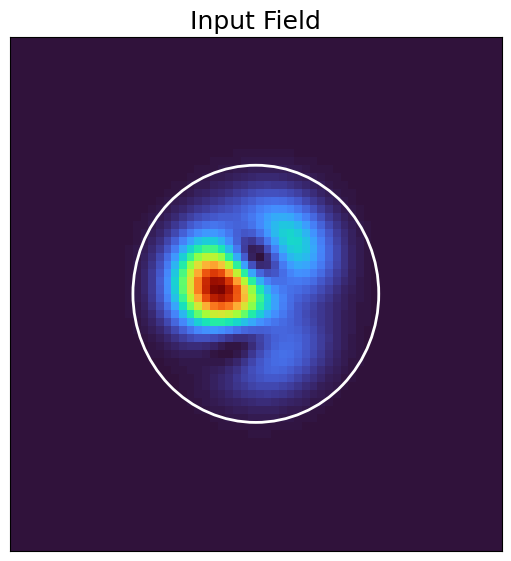

In [76]:
plot_intensity(test_fields_input, radius=core_radius, extent=extent, title='Input Field')

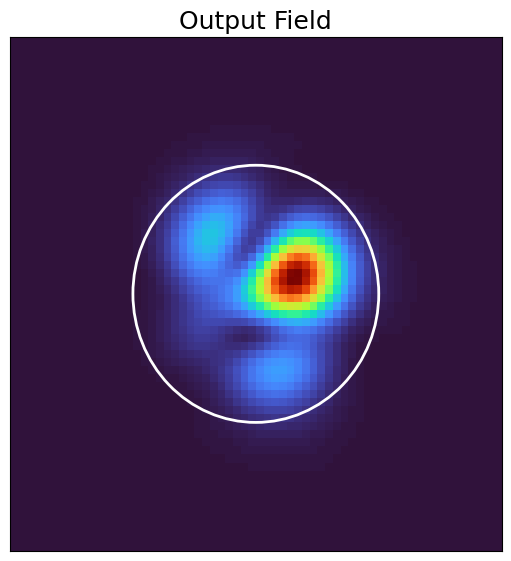

In [77]:
plot_intensity(test_fields_output, radius=core_radius, extent=extent, title='Output Field')

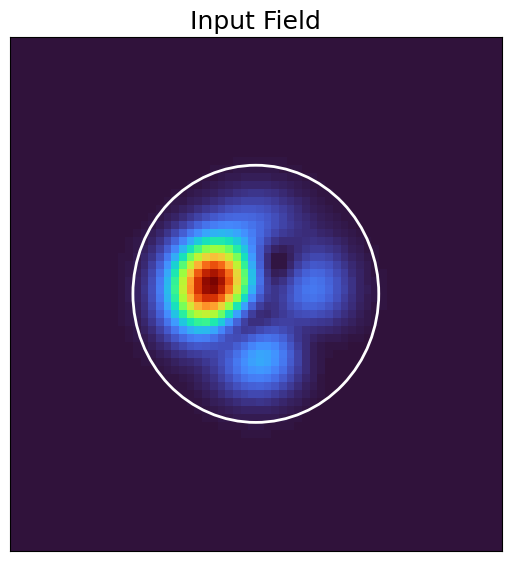

In [10]:
plot_intensity(test_fields_input, radius=core_radius, extent=extent, title='Input Field')

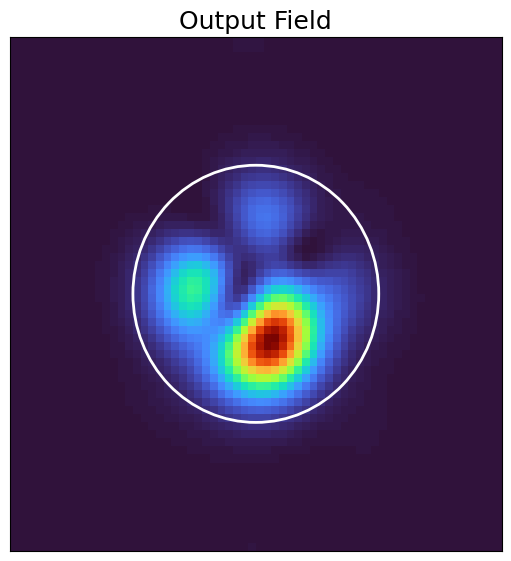

In [13]:
plot_intensity(test_fields_output, radius=core_radius, extent=extent, title='Output Field')

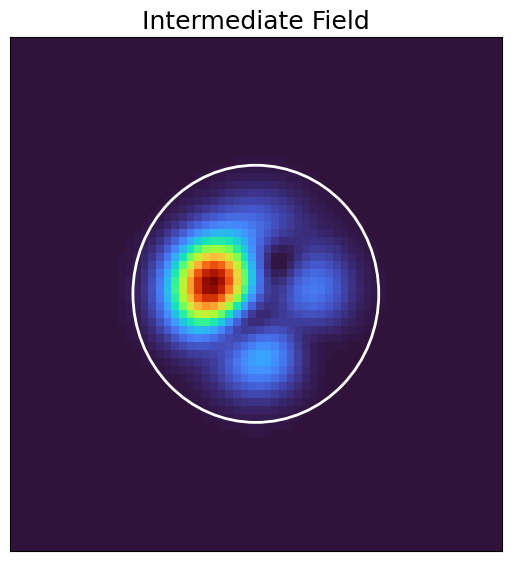

In [14]:
plot_intensity(total_data[0][1], radius=core_radius, extent=extent, title='Intermediate Field')

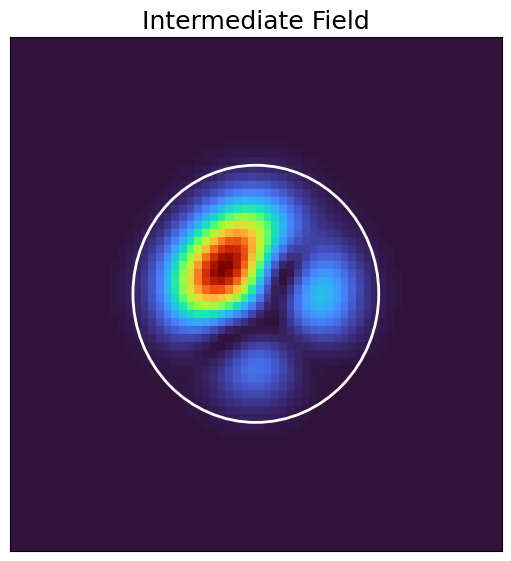

In [15]:
plot_intensity(total_data[0][2], radius=core_radius, extent=extent, title='Intermediate Field')

In [22]:
class SpectralConv3d(nn.Module):
    def __init__(self, in_channels, out_channels, modes, bias=True):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        # modes = (modes_x, modes_y, modes_t)
        self.modes_x, self.modes_y, self.modes_t = modes
        scale = 1 / (in_channels * out_channels)
        self.weight = nn.Parameter(scale * torch.randn(in_channels, out_channels,
                                                       self.modes_x, self.modes_y, self.modes_t, dtype=torch.cfloat))
        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None

    def compl_mul3d(self, input, weights):
        # input: (B, in_c, kx, ky, kt)
        # weights: (in_c, out_c, kx, ky, kt)
        return torch.einsum("bixyz,ioxyz->boxyz", input, weights)

    def forward(self, x):
        B, C, X, Y, T = x.shape
        x = torch.fft.fftn(x, dim=(-3, -2, -1))  # 3D FFT over (x, y, t)
        out = torch.zeros(B, self.out_channels, X, Y, T, dtype=torch.cfloat, device=x.device)

        # Only keep low-frequency modes
        out[:, :, :self.modes_x, :self.modes_y, :self.modes_t] = \
            self.compl_mul3d(x[:, :, :self.modes_x, :self.modes_y, :self.modes_t],
                             self.weight)

        # iFFT back to real space
        out = torch.fft.ifftn(out, dim=(-3, -2, -1))
        if self.bias is not None:
            out = out + self.bias.view(1, -1, 1, 1, 1)
        return out.real  # real tensor for next layers (split real/imag separately later if needed)


# ========================
# 3D FNO Block
# ========================
class FNO3DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, modes=(12, 12, 12), width=64):
        super().__init__()
        self.spectral_conv = SpectralConv3d(in_channels, out_channels, modes)
        self.pointwise_conv = nn.Conv3d(in_channels, out_channels, 1)
        self.activation = nn.GELU()

    def forward(self, x):
        out = self.spectral_conv(x) + self.pointwise_conv(x)
        return x + self.activation(out)
        # return self.activation(out)

# ========================
# 3D FNO Model
# ========================
class FNO3D(nn.Module):
    def __init__(self, in_channels=2, out_channels=2, width=32, n_layers=4,
                 modes=(12, 12, 12)):
        super().__init__()
        self.input_proj = nn.Conv3d(in_channels, width, 1)
        self.fno_layers = nn.ModuleList([
            FNO3DBlock(width, width, modes, width) for _ in range(n_layers)
        ])
        self.output_proj = nn.Sequential(
            nn.Conv3d(width, width // 2, 1),
            nn.GELU(),
            nn.Conv3d(width // 2, out_channels, 1)
        )

    def forward(self, x):
        # x: (B, 2, X, Y, T)
        x = self.input_proj(x)
        for layer in self.fno_layers:
            x = layer(x)
        return self.output_proj(x)

In [23]:
input_data = total_data[:, :1, :, :, :]
output_data = total_data[:, -1, :, :, :]

In [50]:
num_data = total_data.shape[0]
n_train = int(num_data*0.8)
n_test = num_data - n_train
print(f'train : {n_train}, test : {n_test}')

train : 12, test : 4


In [51]:
train_input_data = input_data[0:n_train]
train_output_data = output_data[0:n_train]
test_input_data = input_data[n_train:]
test_output_data = output_data[n_train:]

In [52]:
#complex dtype to real dtype with split real and imag, [M, 1, X, Y, T] -> [M, 2, X, Y, T]
train_input_data = np.concatenate([train_input_data.real, train_input_data.imag], axis=1)
train_output_data = np.concatenate([train_output_data.real, train_output_data.imag], axis=1)
test_input_data = np.concatenate([test_input_data.real, test_input_data.imag], axis=1)
test_output_data = np.concatenate([test_output_data.real, test_output_data.imag], axis=1)
print(train_input_data.shape, train_output_data.shape, flush=True)
print(test_input_data.shape, test_output_data.shape, flush=True)

(12, 2, 64, 64, 2048) (12, 2, 64, 64, 2048)
(4, 2, 64, 64, 2048) (4, 2, 64, 64, 2048)


In [ ]:
# Hyperparameters
lr = 0.01
batch_size = 4
epochs = 50
width = 16
num_layers = 4
mode_x, mode_y, mode_t = 16, 16, 16

In [81]:
# Define a model
model = FNO3D(
        in_channels=2,
        out_channels=2,
        width=width,
        n_layers=num_layers,
        modes=(mode_x, mode_y, mode_t),
        ).to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
loss_fn = nn.MSELoss()


In [40]:
# Print the number of tunable parameters
print('Number of parameters : ',flush=True)
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

Number of parameters : 
4195658


In [41]:
total_loss = 0
total_test_loss = 0
eps = 1e-8
total_loss_list = []
total_test_loss_list = []

# scaler = torch.cuda.amp.GradScaler()    

for epoch in range(epochs):
    model.train()
    for i in range(0, train_input_data.shape[0], batch_size):
        optimizer.zero_grad()
        inp = torch.tensor(train_input_data[i:i+batch_size], device=device)
        target = torch.tensor(train_output_data[i:i+batch_size], device=device)
        out = model(inp)
        loss = loss_fn(out, target) / (torch.mean(target**2) + eps)
        # with torch.cuda.amp.autocast():
        #     out = model(inp)        
        #     loss = loss_fn(out, target) / (torch.mean(target**2) + eps)
        total_loss = total_loss + loss.item()             
         
        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()        
        loss.backward()
        optimizer.step()
        scheduler.step()
        # print(f"Epoch {epoch}, batch {i} training complete", flush=True)
    
    model.eval()
    with torch.no_grad():
        for i in range(0, test_input_data.shape[0], batch_size):
            test_input = torch.tensor(test_input_data[i:i+batch_size], device=device)
            test_target = torch.tensor(test_output_data[i:i+batch_size], device=device)
            test_out = model(test_input)
            test_loss = loss_fn(test_out, test_target) / (torch.mean(test_target**2) + eps)
            total_test_loss = total_test_loss + test_loss.item()
        
    print(f"Epoch {epoch}, Train Loss: {total_loss / n_train}, Test Loss: {total_test_loss / n_test}", flush=True)
    total_loss_list.append(total_loss / 900)
    total_test_loss_list.append(total_test_loss / 100)
    total_loss = 0
    total_test_loss = 0

Epoch 0, Train Loss: 0.2599816421667735, Test Loss: 0.24940632283687592
Epoch 1, Train Loss: 0.2405546655257543, Test Loss: 0.24786485731601715
Epoch 2, Train Loss: 0.23306264479955038, Test Loss: 0.24936264753341675
Epoch 3, Train Loss: 0.22979790965716043, Test Loss: 0.2449951469898224
Epoch 4, Train Loss: 0.22648504376411438, Test Loss: 0.24388183653354645
Epoch 5, Train Loss: 0.2231705735127131, Test Loss: 0.24342849850654602
Epoch 6, Train Loss: 0.2194773256778717, Test Loss: 0.2419680505990982
Epoch 7, Train Loss: 0.21541067957878113, Test Loss: 0.24370324611663818
Epoch 8, Train Loss: 0.21101555724938711, Test Loss: 0.24288822710514069
Epoch 9, Train Loss: 0.20605692267417908, Test Loss: 0.24106499552726746
Epoch 10, Train Loss: 0.2000878651936849, Test Loss: 0.24259285628795624
Epoch 11, Train Loss: 0.19378595550855002, Test Loss: 0.23859336972236633
Epoch 12, Train Loss: 0.1870132734378179, Test Loss: 0.24228057265281677
Epoch 13, Train Loss: 0.17951107521851858, Test Loss: 0.

In [85]:
def train_one_epoch(model, data, batch_size, optimizer, loss_fn, device, eps=1e-8):
    """
    Train for one epoch: predict next z-step from current z-step
    
    Args:
        model: FNO3D model
        data: (n_samples, n_z_steps, 2, Nx, Ny, Nt)
        batch_size: batch size
        optimizer: optimizer
        loss_fn: loss function
        device: device
        eps: epsilon for normalization
    
    Returns:
        average loss for the epoch
    """
    model.train()
    
    n_samples = data.shape[0]
    n_z_steps = data.shape[1]
    
    # Create all (z_i -> z_i+1) pairs
    # For each sample, we have (n_z_steps - 1) training pairs
    all_pairs = []
    
    for sample_idx in range(n_samples):
        for z_idx in range(n_z_steps - 1):
            input_field = data[sample_idx, z_idx]      # (2, Nx, Ny, Nt)
            target_field = data[sample_idx, z_idx + 1]  # (2, Nx, Ny, Nt)
            all_pairs.append((input_field, target_field))
    
    # Shuffle pairs for better training
    indices = torch.randperm(len(all_pairs))
    
    total_loss = 0
    num_batches = 0
    
    for i in range(0, len(all_pairs), batch_size):
        batch_indices = indices[i:i+batch_size]
        
        # Gather batch
        batch_inputs = []
        batch_targets = []
        
        for idx in batch_indices:
            inp, tgt = all_pairs[idx]
            batch_inputs.append(inp)
            batch_targets.append(tgt)
        
        batch_inputs = torch.stack(batch_inputs).to(device)    # (B, 2, Nx, Ny, Nt)
        batch_targets = torch.stack(batch_targets).to(device)  # (B, 2, Nx, Ny, Nt)
        
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(batch_inputs)
        
        # Compute loss
        loss = loss_fn(predictions, batch_targets)
        loss = loss / (torch.mean(batch_targets**2) + eps)
        
        total_loss += loss.item()
        num_batches += 1
        
        # Backward pass
        loss.backward()
        optimizer.step()
        scheduler.step()
    
    return total_loss / num_batches


# ========================
# Test Function
# ========================
def test_one_epoch(model, data, batch_size, loss_fn, device, eps=1e-8):
    """
    Test for one epoch: predict next z-step from current z-step
    
    Args:
        model: FNO3D model
        data: (n_samples, n_z_steps, 2, Nx, Ny, Nt)
        batch_size: batch size
        loss_fn: loss function
        device: device
        eps: epsilon for normalization
    
    Returns:
        average loss for the epoch
    """
    model.eval()
    
    n_samples = data.shape[0]
    n_z_steps = data.shape[1]
    
    # Create all (z_i -> z_i+1) pairs
    all_pairs = []
    
    for sample_idx in range(n_samples):
        for z_idx in range(n_z_steps - 1):
            input_field = data[sample_idx, z_idx]
            target_field = data[sample_idx, z_idx + 1]
            all_pairs.append((input_field, target_field))
    
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for i in range(0, len(all_pairs), batch_size):
            # Gather batch
            batch_inputs = []
            batch_targets = []
            
            for j in range(i, min(i + batch_size, len(all_pairs))):
                inp, tgt = all_pairs[j]
                batch_inputs.append(inp)
                batch_targets.append(tgt)
            
            batch_inputs = torch.stack(batch_inputs).to(device)
            batch_targets = torch.stack(batch_targets).to(device)
            
            # Forward pass
            predictions = model(batch_inputs)
            
            # Compute loss
            loss = loss_fn(predictions, batch_targets)
            loss = loss / (torch.mean(batch_targets**2) + eps)
            
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches


# ========================
# Autoregressive Prediction
# ========================
def predict_autoregressive(model, initial_field, n_steps, device):
    """
    Autoregressively predict n_steps into the future
    
    Args:
        model: FNO3D model
        initial_field: (1, 2, Nx, Ny, Nt) or (2, Nx, Ny, Nt)
        n_steps: number of steps to predict
        device: device
    
    Returns:
        predictions: list of n_steps predicted fields
    """
    model.eval()
    
    # Ensure batch dimension
    if initial_field.ndim == 4:
        initial_field = initial_field.unsqueeze(0)
    
    predictions = []
    current = initial_field.to(device)
    
    with torch.no_grad():
        for _ in range(n_steps):
            next_field = model(current)
            predictions.append(next_field.cpu())
            current = next_field
    
    return predictions


In [56]:
num_samples = total_data.shape[0]
n_z_steps = total_data.shape[1]
print(num_samples, n_z_steps)

16 21


In [69]:
base_model = FNO3D(
    in_channels=2,
    out_channels=2,
    width=width,
    n_layers=num_layers,
    modes=(mode_x, mode_y, mode_t),
).to(device)

# Wrap with autoregressive wrapper
model = AutoregressiveFNO3D(base_model).to(device)
n_autoreg_steps = 1

In [68]:
n_train = int(num_samples * 0.8)
n_test = num_samples - n_train
print(f'Train samples: {n_train}, Test samples: {n_test}')
print(f'Z-steps per sample: {n_z_steps}')

train_data = total_data[:n_train]
test_data = total_data[n_train:]

train_data = np.reshape(train_data, (n_train, n_z_steps, 1, 64, 64, 2048))
test_data = np.reshape(test_data, (n_test, n_z_steps, 1, 64, 64, 2048))
train_data = torch.tensor(np.concatenate([train_data.real, train_data.imag], axis=2))
test_data = torch.tensor(np.concatenate([test_data.real, test_data.imag], axis=2))

print(train_data.shape)

Train samples: 12, Test samples: 4
Z-steps per sample: 21
torch.Size([12, 21, 2, 64, 64, 2048])


In [71]:
train_loss_list = []
test_loss_list = []

In [83]:
for epoch in range(epochs):
    # Train
    train_loss = train_one_epoch(model, train_data, batch_size, optimizer, loss_fn, device, eps)
    
    # Test
    test_loss = test_one_epoch(model, test_data, batch_size, loss_fn, device, eps)
    
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    
    print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}", flush=True)
    
    # Save checkpoint
    if (epoch + 1) % 20 == 0:
        checkpoint_path = f"checkpoint_epoch_{epoch+1}.pth"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'test_loss': test_loss,
        }, checkpoint_path)
        print(f"  Saved checkpoint: {checkpoint_path}")

Epoch   1/100 | Train Loss: 0.819229 | Test Loss: 0.906156
Epoch   2/100 | Train Loss: 0.767633 | Test Loss: 0.903844
Epoch   3/100 | Train Loss: 0.745075 | Test Loss: 0.910687
Epoch   4/100 | Train Loss: 0.696931 | Test Loss: 0.939080
Epoch   5/100 | Train Loss: 0.656833 | Test Loss: 0.885911
Epoch   6/100 | Train Loss: 0.603406 | Test Loss: 0.894251
Epoch   7/100 | Train Loss: 0.570576 | Test Loss: 0.860372
Epoch   8/100 | Train Loss: 0.519423 | Test Loss: 0.888882
Epoch   9/100 | Train Loss: 0.488788 | Test Loss: 0.851382
Epoch  10/100 | Train Loss: 0.445023 | Test Loss: 0.869341
Epoch  11/100 | Train Loss: 0.440852 | Test Loss: 0.819184
Epoch  12/100 | Train Loss: 0.396701 | Test Loss: 0.820602
Epoch  13/100 | Train Loss: 0.382250 | Test Loss: 0.816971
Epoch  14/100 | Train Loss: 0.349246 | Test Loss: 0.833802
Epoch  15/100 | Train Loss: 0.333824 | Test Loss: 0.795033
Epoch  16/100 | Train Loss: 0.318429 | Test Loss: 0.774649
Epoch  17/100 | Train Loss: 0.307894 | Test Loss: 0.7830

KeyboardInterrupt: 

In [84]:
train_loss_list = []
test_loss_list = []

In [ ]:
for epoch in range(epochs):
    # Train
    train_loss = train_one_epoch(model, train_data, batch_size, optimizer, loss_fn, device, eps)
    
    # Test
    test_loss = test_one_epoch(model, test_data, batch_size, loss_fn, device, eps)
    
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    
    print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}", flush=True)
    
    # Save checkpoint
    if (epoch + 1) % 20 == 0:
        checkpoint_path = f"checkpoint_epoch_{epoch+1}.pth"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'test_loss': test_loss,
        }, checkpoint_path)
        print(f"  Saved checkpoint: {checkpoint_path}")

Epoch   1/100 | Train Loss: 0.246339 | Test Loss: 0.736974
Epoch   2/100 | Train Loss: 0.212886 | Test Loss: 0.745345
Epoch   3/100 | Train Loss: 0.217104 | Test Loss: 0.748949
Epoch   4/100 | Train Loss: 0.231871 | Test Loss: 0.739794
Epoch   5/100 | Train Loss: 0.205777 | Test Loss: 0.734844
Epoch   6/100 | Train Loss: 0.197071 | Test Loss: 0.732518
Epoch   7/100 | Train Loss: 0.217347 | Test Loss: 0.726154
Epoch   8/100 | Train Loss: 0.209904 | Test Loss: 0.732888
Epoch   9/100 | Train Loss: 0.185233 | Test Loss: 0.730932
Epoch  10/100 | Train Loss: 0.207592 | Test Loss: 0.757444
Epoch  11/100 | Train Loss: 0.218560 | Test Loss: 0.720539
Epoch  12/100 | Train Loss: 0.182656 | Test Loss: 0.730767
Epoch  13/100 | Train Loss: 0.186459 | Test Loss: 0.740032
Epoch  14/100 | Train Loss: 0.211317 | Test Loss: 0.730146
Epoch  15/100 | Train Loss: 0.182078 | Test Loss: 0.725155
Epoch  16/100 | Train Loss: 0.170958 | Test Loss: 0.729613
Epoch  17/100 | Train Loss: 0.198349 | Test Loss: 0.7482